# Sampling and post-processing of data

Actions:
- Read simulation output in its different formats
- Adaptation to ML-compatible structures (matrix, implicit representations...)
- Save ready for usage

In [3]:
import json
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay, KDTree
from scipy.interpolate import LinearNDInterpolator

In [4]:
RESOLUTION = (32, 32)

dataset_path = Path.cwd() / "data/01_raw/test_TGV"

In [ ]:
output_path = Path.cwd() / "intermediate/" / (dataset_path.name + "_regular")
Path(output_path).mkdir(parents=True, exist_ok=True)
cases = sorted([folder.name for folder in dataset_path.iterdir() if folder.is_dir()], key=lambda x: float(x))

# Obtain grid from original mesh
with h5py.File(dataset_path / "mesh.h5", "r") as file:
    x = file["points"][:,0]
    y = file["points"][:,1]

points = np.column_stack((x, y))
triangulation = Delaunay(points)    # Precompute triangulation for faster linear interpolation
tree = KDTree(points)               # For nearest neighbor interpolation
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), RESOLUTION[0]),
    np.linspace(y.min(), y.max(), RESOLUTION[1])
)
edges_computed = False              # Otherwise linear interpolation sets edge values to NaN
# distance_from_center = np.sqrt((grid_x - cylinder_center[0])**2 + (grid_y - cylinder_center[1])**2)
# solid_mask = distance_from_center < cylinder_radius

In [ ]:
# Iterate through each case in the dataset
def process_case(case_name, debug=False):
    case_path = dataset_path / case_name
    snaps = sorted([file.stem for file in case_path.iterdir() if file.stem != "constant"], key=lambda x: float(x))
    
    Nsnaps = len(snaps)
    grid_Ux = np.zeros((Nsnaps, RESOLUTION[1], RESOLUTION[0]))
    grid_Uy = np.zeros((Nsnaps, RESOLUTION[1], RESOLUTION[0]))
    grid_p = np.zeros((Nsnaps, RESOLUTION[1], RESOLUTION[0]))

    # Iterate through each snapshot and interpolate the data onto the grid
    for i, snap in enumerate(snaps):
        with h5py.File(case_path / (snap + ".h5"), "r") as file:
            Ux = file["U"][:,0]
            Uy = file["U"][:,1]
            p = file["p"][:]
        
        interpolator_Ux = LinearNDInterpolator(triangulation, Ux)
        interpolator_Uy = LinearNDInterpolator(triangulation, Uy)
        interpolator_p = LinearNDInterpolator(triangulation, p)

        if edges_computed == False:
            grid_Ux[i] = interpolator_Ux((grid_x, grid_y))
            edge_mask = np.isnan(grid_Ux[i])
            edge_coords = np.column_stack((grid_x[edge_mask], grid_y[edge_mask]))
            _, edge_indices = tree.query(edge_coords, k=1)

        grid_Ux[i] = interpolator_Ux((grid_x, grid_y))
        grid_Ux[i][edge_mask] = Ux[edge_indices]
        grid_Uy[i] = interpolator_Uy((grid_x, grid_y))
        grid_Uy[i][edge_mask] = Uy[edge_indices]
        grid_p[i] = interpolator_p((grid_x, grid_y))
        grid_p[i][edge_mask] = p[edge_indices]

    # Set the interpolated values inside the cylinder to zero
    # grid_Ux[:,solid_mask] = 0
    # grid_Uy[:,solid_mask] = 0
    # grid_p[:,solid_mask] = 0

    # Load case parameters
    with h5py.File(case_path / "constant.h5", "r") as file:
        nu = file.attrs["nu"]
    Re = 1*2/nu #HARDCODED

    if debug is True:
        return Ux, grid_Ux

    # Save the interpolated data to a single HDF5 file
    with h5py.File(output_path / (case_name + ".h5"), "w") as file:
        file.create_dataset('Ux', data=grid_Ux)
        file.create_dataset('Uy', data=grid_Uy)
        file.create_dataset('p', data=grid_p)
        file.attrs['Reynolds'] = Re

    return Re

from joblib import Parallel, delayed
Re = Parallel(n_jobs=-1)(delayed(process_case)(case_name) for case_name in tqdm(cases))

# Save the summary
summary = pd.DataFrame(columns=['Reynolds'], index=cases)
summary["Reynolds"] = Re
summary.to_csv(output_path / 'summary.csv', index_label='Name')
summary.head()

100%|██████████| 160/160 [00:12<00:00, 13.05it/s]


,Reynolds
0,41.0
1,42.0
2,43.0
3,44.0
4,45.0


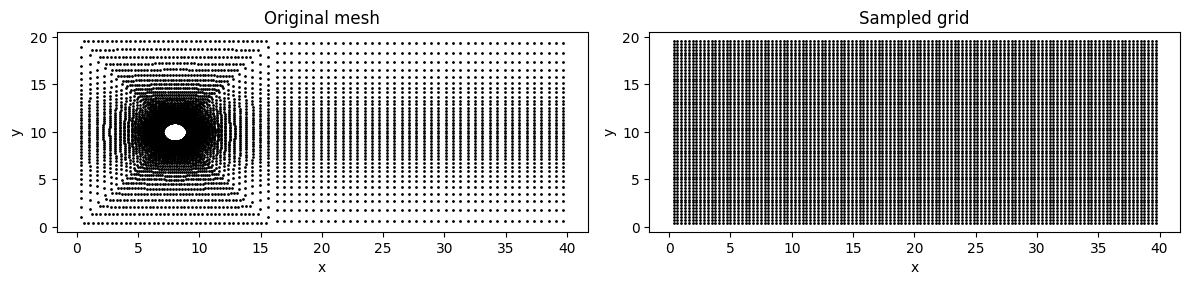

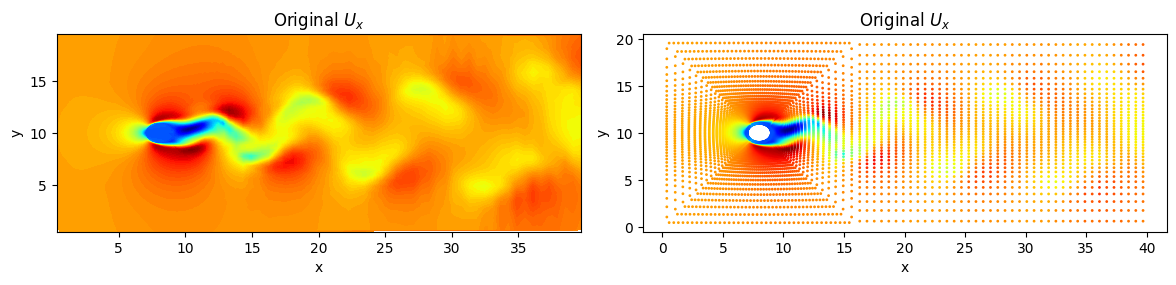

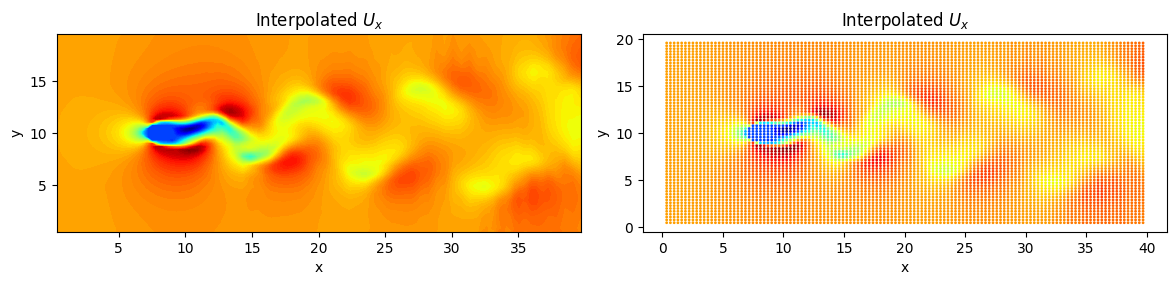

In [5]:
Ux, grid_Ux = process_case(cases[-1], debug=True)  # For visualization
grid_Ux = grid_Ux[-1]

figratio = y.max() / x.max()
figLength = 6

# Plot the original mesh and the sampled grid
fig, axes = plt.subplots(1, 2, figsize=(2*figLength, figLength*figratio))
ax = axes[0]
ax.scatter(points[:,0], points[:,1], s=1, c='k')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Original mesh')

ax = axes[1]
ax.scatter(grid_x, grid_y, c='k', s=1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Sampled grid')

plt.tight_layout()
plt.show()

# Plot the original and interpolated Ux
fig, axes = plt.subplots(1, 2, figsize=(2*figLength, figLength*figratio))
ax = axes[0]
ax.tricontourf(x, y, Ux, levels = 100, cmap = 'jet')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Original $U_x$')

ax = axes[1]
ax.scatter(x, y, c=Ux, s=1, cmap='jet')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Original $U_x$')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(2*figLength, figLength*figratio))
ax = axes[0]
ax.contourf(grid_x, grid_y, grid_Ux, levels=100, cmap='jet')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Interpolated $U_x$')

ax = axes[1]
plt.scatter(grid_x, grid_y, c=grid_Ux, s=1, cmap='jet')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Interpolated $U_x$')

plt.tight_layout()
plt.show()